# HW 3 Regression's Feature Selection with Ant Colony method and Gradient Boosting

## Dataset description

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("meruvakodandasuraj/e-commerce-customer-behavior-and-sales-20202026")

print("Path to dataset files:", path)

100%|██████████| 1.31M/1.31M [00:01<00:00, 1.07MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/meruvakodandasuraj/e-commerce-customer-behavior-and-sales-20202026/versions/1


Электронная коммерция (E-commerce) и аналитика розничных онлайн-продаж. Данные отражают активность покупателей и историю транзакций за 6 лет (период с 2020 по 2026 год) по 20 странам и 14 категориям товаров.

Данные распределены по нескольким таблицам, но базовой для анализа поведения клиентов является customers.csv (8000 объектов, 20 столбцов)

Основные группы признаков:
- Демографические метрики: country (страна проживания клиента), age (возраст), gender (пол: Male / Female / Other).

- Профиль лояльности: membership_tier (уровень подписки: Free, Silver, Gold, Platinum), registration_date (дата создания аккаунта).

- Поведенческие факторы и RFM-анализ: total_orders (общее число заказов), days_since_last_purchase (показатель Recency — сколько дней назад был совершен последний заказ).

- Взаимодействие и фидбек: avg_review_score (средняя оценка товаров от 1 до 5), returns_made (количество оформленных возвратов).

- Финансовые маркеры: total_spend_usd (суммарные траты) и avg_order_value_usd (средний чек).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as md
%matplotlib inline
plt.style.use('bmh'); sns.set_style("whitegrid")
plt.rc('xtick', labelsize=15); plt.rc('ytick', labelsize=15)
import warnings
warnings.simplefilter(action='ignore')

df = pd.read_csv(f"{path}/customers.csv")

In [ ]:
df.head()

,customer_id,country,age,gender,membership_tier,registration_date,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
0,C00001,United States,40,Male,Free,2019-01-17,4,286.63,63.78,49,Food & Grocery,Mobile,Debit Card,Social Media,1,4.5,0,12,0,0
1,C00002,United States,20,Female,Free,2026-03-04,11,1245.18,107.32,126,Toys & Games,Mobile,Debit Card,Organic Search,2,2.6,1,1,0,0
2,C00003,United States,43,Female,Gold,2026-02-08,4,195.37,42.74,0,Home & Kitchen,Mobile,PayPal,Referral,0,4.8,0,0,1,0
3,C00004,United States,41,Male,Free,2025-03-19,6,99.45,15.61,6,Electronics,Desktop,PayPal,Organic Search,2,4.2,0,8,1,0
4,C00005,France,37,Other,Platinum,2024-09-10,36,2593.21,79.09,161,Clothing & Apparel,Tablet,Debit Card,Social Media,9,4.0,4,5,1,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               8000 non-null   object 
 1   country                   8000 non-null   object 
 2   age                       8000 non-null   int64  
 3   gender                    8000 non-null   object 
 4   membership_tier           8000 non-null   object 
 5   registration_date         8000 non-null   object 
 6   total_orders              8000 non-null   int64  
 7   total_spend_usd           8000 non-null   float64
 8   avg_order_value_usd       8000 non-null   float64
 9   days_since_last_purchase  8000 non-null   int64  
 10  preferred_category        8000 non-null   object 
 11  preferred_device          8000 non-null   object 
 12  preferred_payment_method  8000 non-null   object 
 13  acquisition_channel       8000 non-null   object 
 14  reviews_

In [ ]:
df.describe()

,age,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,35.616375,16.545250,1558.642350,94.845566,59.583875,3.228750,4.109112,0.849500,4.457125,0.617375,0.089375
std,11.170455,14.681064,2284.094953,78.992885,60.610355,3.942698,0.523992,1.407337,4.854391,0.486058,0.285302
min,18.000000,1.000000,4.890000,5.000000,0.000000,0.000000,1.800000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,5.000000,336.055000,44.690000,16.000000,0.000000,3.800000,0.000000,1.000000,0.000000,0.000000
50%,35.000000,12.000000,845.700000,72.270000,41.000000,2.000000,4.200000,0.000000,3.000000,1.000000,0.000000
75%,43.000000,23.000000,1892.165000,118.560000,84.000000,5.000000,4.500000,1.000000,6.000000,1.000000,0.000000
max,75.000000,79.000000,61282.480000,1051.730000,582.000000,28.000000,5.000000,11.000000,41.000000,1.000000,1.000000


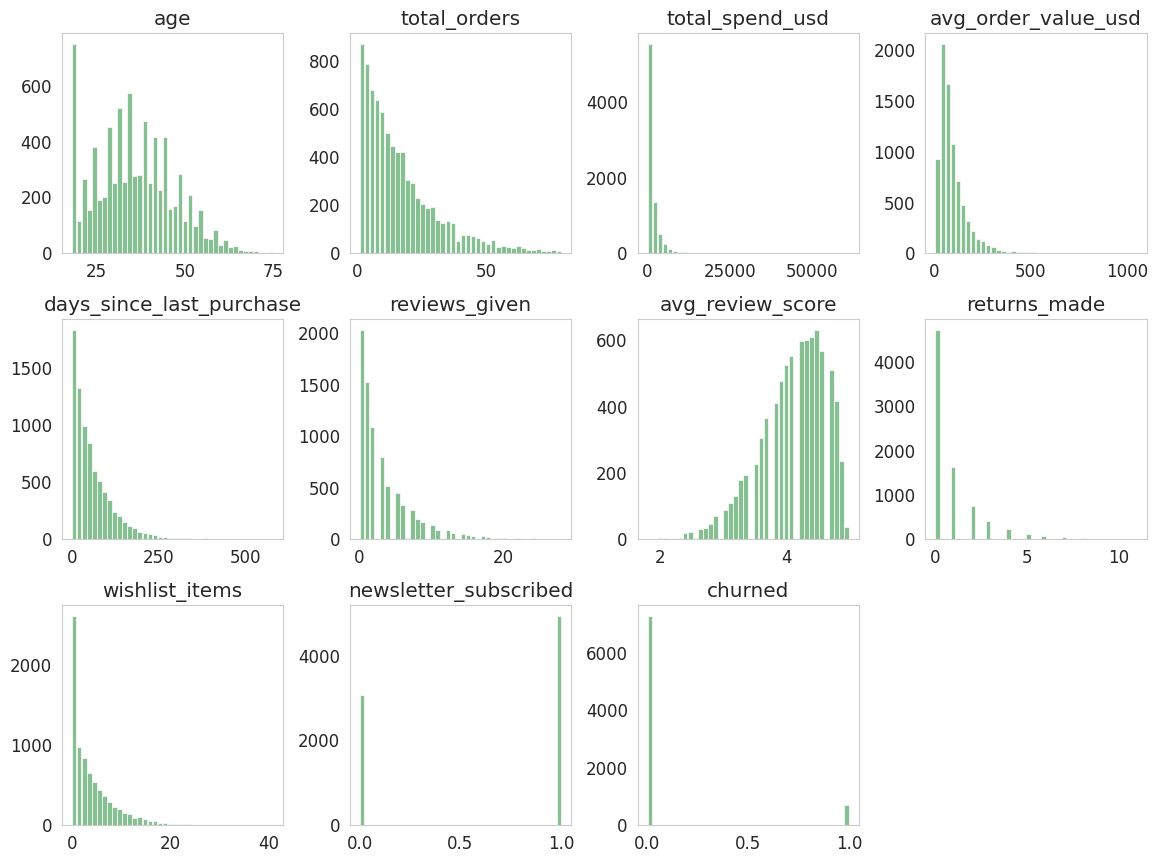

In [ ]:
ax = df.hist(bins=40, grid=False, figsize=(14,14), layout=(4,4), color='#86bf91',
                      zorder=2, rwidth=0.9, xlabelsize=12, ylabelsize=12)

## Data preprocessing

- по результатам `df.describe()` заметно, что выборка в датасете уже заметно отфильтрована и не имеет значений, которые противоречили бы доменам
- по результатам построения диаграмм вызывают подозрения распределения age и total_orders, они могут быть вызваны вмешательством в процессе предподготовки данных или характером разбиения на корзины данных, однако методы должны будут отклонить такие столбцы, ведь если данные плохие, то они не будут определять результат

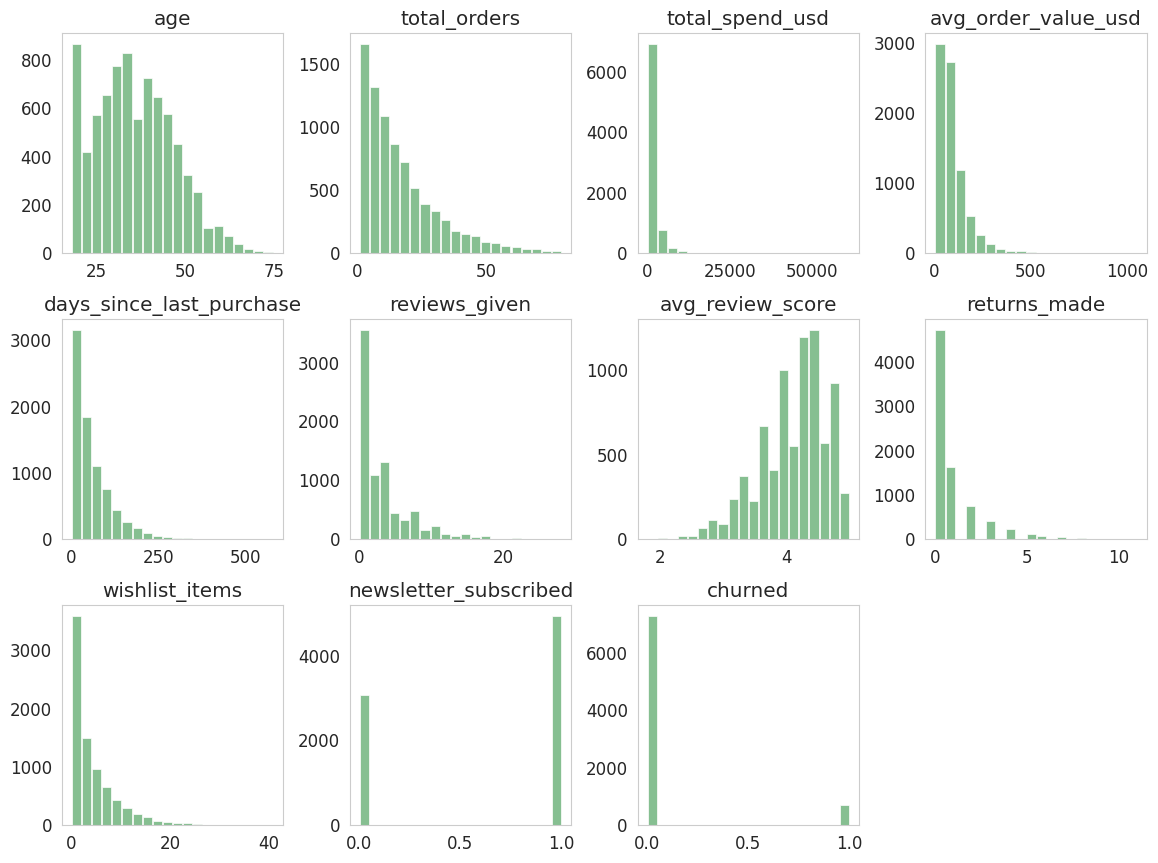

In [ ]:
ax = df.hist(bins=20, grid=False, figsize=(14,14), layout=(4,4), color='#86bf91',
                      zorder=2, rwidth=0.9, xlabelsize=12, ylabelsize=12)

- можно заметить, что расчёска сместилась, поэтому кажется необязательным её учитывать как странность в распределении данных

### Уберём строки с нетипичными значениями

In [ ]:
# from typing import NamedTuple
# import numpy as np

# Rule = NamedTuple("data_limits", [('low_lim', float), ('upper_lim', float)])

# preprocessing_rules = dict(
#     **{
#         # Например, возраст клиентов. Отсекаем младше 18 и старше 100 лет
#         'age': Rule(17, 100),

#         # Общее число заказов (минимум 1, максимум пусть будет 500)
#         'total_orders': Rule(0, 500),

#         # Общие траты (отсекаем отрицательные или нулевые значения)
#         'total_spend_usd': Rule(0, 100000),

#         # Средний чек (не может быть отрицательным)
#         'avg_order_value_usd': Rule(0, 5000),

#         # Дней с последней покупки (от 0 до, скажем, 3000 дней)
#         'days_since_last_purchase': Rule(-1, 3000),

#         # Оценки (рейтинг обычно от 1 до 5)
#         'avg_review_score': Rule(0, 5.1),
#     }
# )

# for f, rule in preprocessing_rules.items():
#     if f in df.columns:
#         df.loc[(df[f] <= rule.low_lim) | (df[f] >= rule.upper_lim), f] = np.nan

# print("Количество строк до удаления NaN:", len(df))

# df.dropna(inplace=True)

# print("Количество строк после удаления NaN:", len(df))

In [ ]:
# df = df[(df.index > '2022-10-01') & (df.index < '2022-12-01')]
# print(len(df))

In [ ]:
# ax = df.hist(bins=50, grid=False, figsize=(14,14), layout=(4,4), color='#86bf91',
#                       zorder=2, rwidth=0.9, xlabelsize=12, ylabelsize=12)

### Divide dataset

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

TARGET = 'total_spend_usd'
# Define all candidate features, excluding the target
all_candidate_features = [col for col in df.columns if col != TARGET]

# Identify numerical and categorical columns among the candidate features
numerical_features = df[all_candidate_features].select_dtypes(include=np.number).columns.tolist()
categorical_features = df[all_candidate_features].select_dtypes(include='object').columns.tolist()

# Create a preprocessor to handle both numerical and categorical features
# Numerical features will be scaled, categorical features will be one-hot encoded
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Apply the preprocessor to the entire set of candidate features to create 'all_scaled'
all_scaled = preprocessor.fit_transform(df[all_candidate_features])

# x_train is just the scaled numerical features. This is kept for separate use if needed.
x_train = preprocessor.named_transformers_['num'].transform(df[numerical_features])
y_train = df[TARGET].copy()

print(f"Shape of all_scaled (all features, scaled/encoded): {all_scaled.shape}")
print(f"Shape of x_train (numerical features only, scaled): {x_train.shape}")
print(f"Original df shape: {df.shape}")

Shape of all_scaled (all features, scaled/encoded): (8000, 9929)
Shape of x_train (numerical features only, scaled): (8000, 10)
Original df shape: (8000, 20)


### Feature Importance 1. Градиентный бустинг

In [ ]:
import pickle
from sklearn import ensemble

params = {
    "n_estimators": 300,
    "max_depth": 4,
    "min_samples_split": 10,
    "learning_rate": 0.01,
    "verbose": 0,#1,
}
model_base_full = ensemble.GradientBoostingRegressor(**params)
model_base_full.fit(x_train, y_train)


GradientBoostingRegressor(learning_rate=0.01, max_depth=4, min_samples_split=10,
                          n_estimators=300)

In [ ]:
N_FEATURES = 7

Indices of top features: [2 1 4 5 0 6 3]


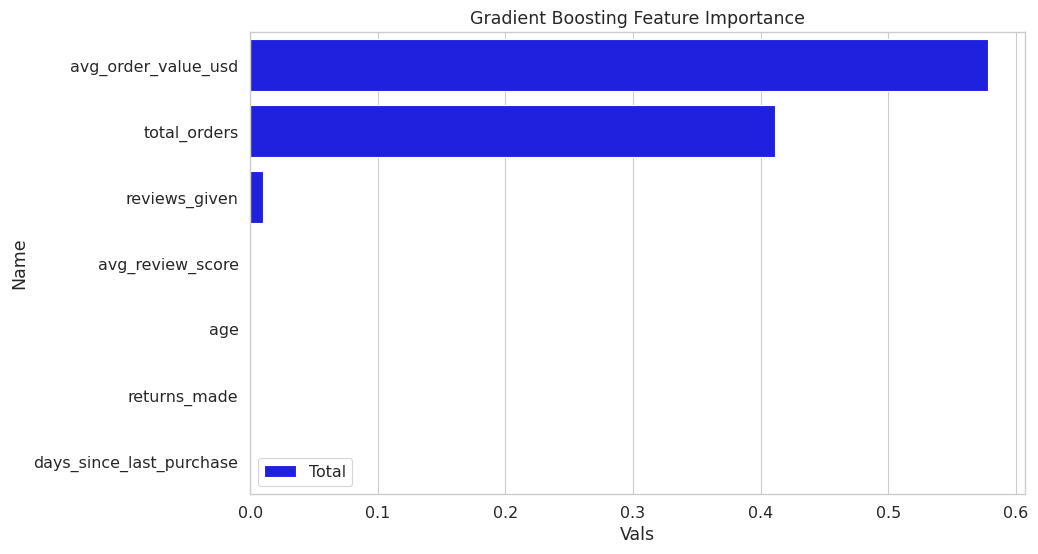

In [ ]:
import copy
base_feature_importance = copy.deepcopy(model_base_full.feature_importances_)
base_feature_importance_sorted_idx = np.argsort(base_feature_importance)[::-1]
base_feature_importance_sorted_idx = base_feature_importance_sorted_idx[0:N_FEATURES]
print(f"Indices of top features: {base_feature_importance_sorted_idx}")

# Используем numerical_features вместо несуществующей FEATURES
boosting_names = [numerical_features[i] for i in base_feature_importance_sorted_idx]
vals = base_feature_importance[base_feature_importance_sorted_idx]
fimps = pd.DataFrame(data={'Name': boosting_names, 'Vals':vals})

sns.set_context("paper", font_scale=1.3)
plt.figure(figsize=(10, 6))
sns.barplot(x="Vals", y="Name", data=fimps, label="Total", color="b")
plt.title("Gradient Boosting Feature Importance")
plt.show()

### Feature Importance 2. Муравьиная колония (UFSACO)

In [ ]:
# Малое число
EPS = 1e-6
# Первоначальное число признаков (теперь берем из all_scaled)
N_START_FEATURES = all_scaled.shape[1]
print(f"Начальное число признаков для ACO: {N_START_FEATURES}")
# Итоговое число признаков
N_END_FEATURES = 7
# Максимально число циклов
NC_MAX = 3
# Число шагов внутри цикла
N_STEPS = 4
# Начальное количество феромона
INIT_PHEROMONE = 0.2
# коэффициент испарения
RO = 0.2
# Вероятность выполнения шага применения (exploitation)
EXPLOITATION_PROB = 0.7
# Параметры относительной важности некоррелированности выбираемых фичей и коррелированности с таргетом относительно желательности фичи.
ALPHA = 1.0
BETA = 1.0
# Число агентов
N_ANTS = 5

Начальное число признаков для ACO: 9929


In [ ]:
# 1. Устанавливаем версию CuPy для актуальной в Colab CUDA 12
try:
    import cupy as cp
    print("CuPy is already installed.")
except ImportError:
    print("Installing CuPy...")
    !pip install cupy-cuda12x
    import cupy as cp

from scipy.sparse import issparse
import numpy as np

def get_gpu_sim_matrix(sparse_data):
    try:
        # Проверяем наличие GPU
        cp.cuda.Device(0).use()

        print("Moving data to GPU and calculating similarity matrix...")
        if issparse(sparse_data):
            data_gpu = cp.array(sparse_data.toarray())
        else:
            data_gpu = cp.array(sparse_data)

        # Нормализация на GPU
        norms = cp.linalg.norm(data_gpu, axis=0)
        norms[norms == 0] = 1.0
        data_gpu = data_gpu / norms

        # Матричное умножение на GPU
        gpu_sim = cp.abs(data_gpu.T @ data_gpu)
        return cp.asnumpy(gpu_sim)

    except Exception as e:
        print(f"GPU calculation failed or not available: {e}")
        print("Falling back to CPU (this may take a few moments)... content...")
        # Fallback на оптимизированный CPU вариант
        from sklearn.preprocessing import normalize
        all_scaled_norm = normalize(sparse_data, axis=0)
        return np.abs((all_scaled_norm.T @ all_scaled_norm).toarray())

# Вычисляем матрицу один раз
sim_matrix = get_gpu_sim_matrix(all_scaled)
print(f"Matrix shape: {sim_matrix.shape} calculation complete.")

def get_sim(i, j):
    return sim_matrix[i, j]

CuPy is already installed.
Moving data to GPU and calculating similarity matrix...
Matrix shape: (9929, 9929) calculation complete.


Теперь, когда `get_sim` просто берет готовое значение из матрицы, вычисленной на CUDA, основной алгоритм `UFSACO_fixed` будет работать значительно быстрее, даже оставаясь на CPU.

In [ ]:
sim = {}
def set_sim(i, j):
    # Extract sparse column vectors
    a_sparse = all_scaled[:, i]
    b_sparse = all_scaled[:, j]

    # Convert sparse column vectors to dense 1D numpy arrays
    a_vec = a_sparse.toarray().flatten()
    b_vec = b_sparse.toarray().flatten()

    # Calculate norms
    norm_a = np.linalg.norm(a_vec)
    norm_b = np.linalg.norm(b_vec)

    # Handle cases where one or both vectors are zero vectors to avoid division by zero
    if norm_a == 0 or norm_b == 0:
        res = 0.0 # Cosine similarity is typically defined as 0 for a zero vector
    else:
        res = np.dot(a_vec, b_vec) / (norm_a * norm_b)

    sim[(min(i, j), max(i, j))] = np.abs(res)
    return res

def get_sim(i, j):
    (i, j) = (min(i, j), max(i, j))
    if (i, j) not in sim.keys():
        set_sim(i, j)
    return sim[(i, j)]




Цикл по этапам перераспределения: count = 0;NC_MAX=3:

    ants_pos = np.random.choice(N_START_FEATURES, size=N_ANTS, p=tau/sum(tau)) # tau - ферромон

    nodes_visited = {(k, i): set()}

    Цикл по длине пути муравья от старта: iter = 0;4:

        Цикл по номерам муравьёв: k=0;5:

            i = ants_pos[k] # номер фичи i, последней для k-го муравья   

            node_score = [tau[j]/cos(i-ая, j-ая фичи) for j in unvisited]

              # подобрать номер фичи jj из unvisited по EXPLORATION / EXPLOITATION
              (Random on distr / ArgMax{node_score}) j = unvisited[jj]

            ants_pos[k] = j     

            nodes_visited[(k, i)].add(j)

    Пересчёт ферромона: tau = (1 - RO) * tau + (visits / total_visits)  # посещения только с текущего этапа
        

In [ ]:
def UFSACO(verbose=True):
    # Инициируем начальным значением феромона в каждом узле
    tau = INIT_PHEROMONE * np.ones((N_START_FEATURES))

    #np.random.seed(1234)
    # Внешний цикл - число эпох
    for count in range(NC_MAX):
        # случайно размещаем муравьёв по узлам с вероятностью, пропорциональной феромону
        ants_pos = np.random.choice(N_START_FEATURES, size=N_ANTS, p=tau/sum(tau))
        # print(ants_pos)

        # Очищаем счётчик посещений узлов для каждого узла
        visits = np.zeros((N_START_FEATURES))

        # Очищаем множество посещённых узлов каждым k-ым агентом из каждого i-ого узла
        nodes_visited = {(k, i): set() for k in range(N_ANTS) for i in range(N_START_FEATURES)}

        # внутренний цикл - длина пути, который проходят все муравьи
        for iter in range(N_STEPS):
            # k - номер текущего муравья
            # самый внутренний - шаг одного муравья
            for k in range(N_ANTS):
                # на каком узле i-ом узле находится k-ый муравей
                i = ants_pos[k]
                # print(i)
                # множество посещённых узлов
                visited = nodes_visited[(k, i)]
                # print(visited)
                # множество непосещённых узлов
                unvisited = list((set(range(N_START_FEATURES)) - visited) - {i})
                # print(unvisited)

                # массив "желательности" узла

                # 1) UFSACO: без учёта таргета
                #print([get_sim(i, j) for j in unvisited])
                node_score = [tau[j] / np.power(get_sim(i, j), ALPHA) for j in unvisited]
                #print(node_score)

                # какой шаг выполняем - exploration или exploitation?
                q = np.random.uniform()
                # print(q)
                if q <= EXPLOITATION_PROB:
                    # EXPLOITATION
                    if verbose:
                        print("EXPLOITATION")
                    # переходим в узел с максомальной желательностью
                    jj = np.argmax(node_score)
                else:
                    # EXPLORATION
                    if verbose:
                        print("EXPLORATION")
                    # переходим по вероятности, пропорциональной желательности
                    p = node_score / sum(node_score)
                    jj = np.random.choice(len(unvisited), size=1, p=p)[0]
                # получаем номер следущего узла j для k: i -> j
                j = unvisited[jj]
                # перемещаем k-ого муравья в j-ый узел
                ants_pos[k] = j
                # добавляем информацию о перемещении
                nodes_visited[(k, i)].add(j)
                # увеличиваем счётчик посещения j-ого узла
                visits[j] += 1
                if verbose:
                    print(f"count={count}, iter={iter}, k={k}, i={i}, j={j}")
        # пересчитываем количество феромона
        total_visits = sum(visits)
        tau = (1 - RO) * tau + (visits / total_visits)
    return tau

### Запустим алгоритм 5 раз и оценим устойчивость при выбранных значениях гиперпараметров

In [ ]:
import cupy as cp

def UFSACO_gpu(verbose=False):
    # Переносим параметры и матрицу на GPU
    sim_matrix_gpu = cp.array(sim_matrix)
    tau = cp.full((N_START_FEATURES,), INIT_PHEROMONE)

    all_input_names = preprocessor.get_feature_names_out()

    for count in range(NC_MAX):
        # 1. Выбираем стартовые позиции для всех муравьев сразу
        prob_dist = tau / cp.sum(tau)
        ants_pos = cp.random.choice(N_START_FEATURES, size=N_ANTS, p=prob_dist)

        # Матрица для отслеживания посещенных узлов (N_ANTS x N_FEATURES)
        visited_mask = cp.zeros((N_ANTS, N_START_FEATURES), dtype=bool)
        visits = cp.zeros(N_START_FEATURES)

        for step in range(N_STEPS):
            # Помечаем текущие позиции как посещенные
            visited_mask[cp.arange(N_ANTS), ants_pos] = True

            # Вычисляем веса для всех возможных следующих шагов
            scores = tau / (cp.power(sim_matrix_gpu[ants_pos], ALPHA) + EPS)

            # Зануляем вероятности для уже посещенных узлов
            scores[visited_mask] = 0

            # Выбираем следующий узел для каждого муравья
            q = cp.random.uniform(size=N_ANTS)
            next_nodes = cp.zeros(N_ANTS, dtype=int)

            # Exploitation
            exploit_mask = (q <= EXPLOITATION_PROB)
            if cp.any(exploit_mask):
                next_nodes[exploit_mask] = cp.argmax(scores[exploit_mask], axis=1)

            # Exploration (вероятностный выбор)
            explore_mask = ~exploit_mask
            if cp.any(explore_mask):
                row_sums = scores[explore_mask].sum(axis=1, keepdims=True)
                row_sums[row_sums == 0] = 1.0
                probs = scores[explore_mask] / row_sums

                for idx in cp.where(explore_mask)[0]:
                    local_idx = cp.where(cp.where(explore_mask)[0] == idx)[0][0]
                    p_row = probs[local_idx]
                    if cp.abs(cp.sum(p_row) - 1.0) > 1e-5:
                        p_row = p_row / cp.sum(p_row)
                    next_nodes[idx] = cp.random.choice(N_START_FEATURES, size=1, p=p_row)[0]

            ants_pos = next_nodes
            # Атомарно добавляем посещения: исправлен вызов scatter_add
            cp.add.at(visits, ants_pos, 1)

        # Обновляем феромон
        total_v = cp.sum(visits)
        if total_v > 0:
            tau = (1 - RO) * tau + (visits / total_v)

    return cp.asnumpy(tau)

print("Запуск ACO на GPU...")
all_input_names = preprocessor.get_feature_names_out()
for a in range(5):
    tau_result = UFSACO_gpu()
    features_UFSACO = tau_result.argsort()[::-1][0:N_END_FEATURES]
    names = [all_input_names[i] for i in features_UFSACO]
    print(f"Run {a+1}: {names}")

Запуск ACO на GPU...
Run 1: ['cat__customer_id_C00001', 'num__returns_made', 'cat__customer_id_C00003', 'cat__customer_id_C00002', 'num__newsletter_subscribed', 'cat__customer_id_C00606', 'cat__customer_id_C00412']
Run 2: ['cat__customer_id_C00003', 'num__returns_made', 'num__churned', 'cat__customer_id_C00001', 'num__days_since_last_purchase', 'cat__customer_id_C00019', 'num__reviews_given']
Run 3: ['num__returns_made', 'cat__customer_id_C00001', 'cat__customer_id_C00003', 'num__newsletter_subscribed', 'num__churned', 'cat__customer_id_C00002', 'cat__registration_date_2023-02-12']
Run 4: ['num__returns_made', 'cat__customer_id_C00001', 'num__newsletter_subscribed', 'cat__customer_id_C00002', 'cat__customer_id_C01438', 'cat__customer_id_C06847', 'cat__customer_id_C03493']
Run 5: ['cat__customer_id_C00001', 'num__returns_made', 'cat__customer_id_C00003', 'num__reviews_given', 'cat__customer_id_C01680', 'cat__customer_id_C05316', 'cat__registration_date_2020-05-09']


### Посмотрим на итоговую схожесть признаков

In [ ]:
import numpy as np
import pandas as pd

# Вместо перебора 49 миллионов пар в цикле (что занимает вечность),
# используем матричные операции и индексы.

# 1. Берем только верхний треугольник матрицы (выше диагонали), чтобы не дублировать пары
# и не считать сходство признака с самим собой (диагональ)
iu = np.triu_indices(sim_matrix.shape[0], k=1)
tri_sims = sim_matrix[iu]

def get_top_pairs(sim_values, indices, names, top_n=10, ascending=False):
    # Сортируем только нужную часть данных
    if ascending:
        sorted_idx = np.argsort(sim_values)[:top_n]
    else:
        sorted_idx = np.argsort(sim_values)[::-1][:top_n]

    results = []
    for idx in sorted_idx:
        i_idx = indices[0][idx]
        j_idx = indices[1][idx]
        pair_name = f"{names[i_idx]} + {names[j_idx]}"
        results.append({"Pair": pair_name, "Similarity": sim_values[idx]})
    return pd.DataFrame(results)

print(f"Всего пар для анализа: {len(tri_sims)}")

print("\nТоп-10 самых похожих признаков:")
display(get_top_pairs(tri_sims, iu, all_input_names, top_n=10, ascending=False))

print("\nТоп-10 самых различных признаков:")
display(get_top_pairs(tri_sims, iu, all_input_names, top_n=10, ascending=True))

Всего пар для анализа: 49287556

Топ-10 самых похожих признаков:


,Pair,Similarity
0,cat__customer_id_C01270 + cat__registration_da...,1.0
1,cat__customer_id_C01420 + cat__registration_da...,1.0
2,cat__customer_id_C03655 + cat__registration_da...,1.0
3,cat__customer_id_C05970 + cat__registration_da...,1.0
4,cat__customer_id_C02669 + cat__registration_da...,1.0
5,cat__customer_id_C06957 + cat__registration_da...,1.0
6,cat__customer_id_C01198 + cat__registration_da...,1.0
7,cat__customer_id_C00717 + cat__registration_da...,1.0
8,cat__customer_id_C05010 + cat__registration_da...,1.0
9,cat__customer_id_C06547 + cat__registration_da...,1.0



Топ-10 самых различных признаков:


,Pair,Similarity
0,cat__customer_id_C04180 + cat__customer_id_C07004,0.0
1,cat__customer_id_C04180 + cat__customer_id_C06993,0.0
2,cat__customer_id_C04180 + cat__customer_id_C06994,0.0
3,cat__customer_id_C04180 + cat__customer_id_C06995,0.0
4,cat__customer_id_C04180 + cat__customer_id_C06996,0.0
5,cat__customer_id_C04180 + cat__customer_id_C06997,0.0
6,cat__customer_id_C04180 + cat__customer_id_C06998,0.0
7,cat__customer_id_C04180 + cat__customer_id_C06999,0.0
8,cat__customer_id_C04180 + cat__customer_id_C07000,0.0
9,cat__customer_id_C04180 + cat__customer_id_C07001,0.0


### Результаты от бустинга и муравьиной колонии

In [ ]:
list(set(names) & set(boosting_names))

[]